In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [5]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")

fraud_df.head()


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [4]:
fraud_df.tail()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
151107,345170,2015-01-27 03:03:34,2015-03-29 00:30:47,43,XPSKTWGPWINLR,SEO,Chrome,M,28,3.451155e+09,1
151108,274471,2015-05-15 17:43:29,2015-05-26 12:24:39,35,LYSFABUCPCGBA,SEO,Safari,M,32,2.439047e+09,0
151109,368416,2015-03-03 23:07:31,2015-05-20 07:07:47,40,MEQHCSJUBRBFE,SEO,IE,F,26,2.748471e+09,0
151110,207709,2015-07-09 20:06:07,2015-09-07 09:34:46,46,CMCXFGRHYSTVJ,SEO,Chrome,M,37,3.601175e+09,0
151111,138208,2015-06-10 07:02:20,2015-07-21 02:03:53,20,ZINIADFCLHYPG,Direct,IE,M,38,4.103825e+09,0


In [6]:
print("Rows and Columns:")
print(fraud_df.shape)

Rows and Columns:
(151112, 11)


In [8]:
fraud_df.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class'],
      dtype='object')

In [9]:
fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


In [10]:
missing_values = fraud_df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage":
        (missing_values / len(fraud_df)) * 100
})

missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
user_id,0,0.0
signup_time,0,0.0
purchase_time,0,0.0
purchase_value,0,0.0
device_id,0,0.0
source,0,0.0
browser,0,0.0
sex,0,0.0
age,0,0.0
ip_address,0,0.0


### Interpretation

The dataset was examined for missing values across all features.

No missing value issues were identified. Therefore, no imputation was required.

If missing values had been present, median imputation would have been considered for numerical variables and mode imputation for categorical variables.

In [11]:
duplicates = fraud_df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [40]:
fraud_df = fraud_df.drop_duplicates()

fraud_df.duplicated().sum()

np.int64(0)

In [12]:
fraud_df = fraud_df.drop_duplicates()

print(fraud_df.shape)

(151112, 11)


In [13]:
fraud_df["signup_time"] = pd.to_datetime(
    fraud_df["signup_time"]
)

fraud_df["purchase_time"] = pd.to_datetime(
    fraud_df["purchase_time"]
)

In [14]:
fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[ns]
 2   purchase_time   151112 non-null  datetime64[ns]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  object        
 5   source          151112 non-null  object        
 6   browser         151112 non-null  object        
 7   sex             151112 non-null  object        
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(4), object(4)
memory usage: 12.7+ MB


In [15]:
fraud_df.describe()

,user_id,signup_time,purchase_time,purchase_value,age,ip_address,class
count,151112.000000,151112,151112,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,2015-04-20 00:56:09.511329280,2015-06-16 02:56:38.759952896,36.935372,33.140704,2.152145e+09,0.093646
min,2.000000,2015-01-01 00:00:42,2015-01-01 00:00:44,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,2015-02-18 09:52:48.500000,2015-04-18 14:41:25.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,2015-04-19 04:41:30,2015-06-18 13:46:17.500000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,2015-06-18 14:47:22.750000128,2015-08-17 18:48:31.500000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,2015-08-18 04:40:29,2015-12-16 02:56:05,154.000000,76.000000,4.294850e+09,1.000000
std,115369.285024,NaN,NaN,18.322762,8.617733,1.248497e+09,0.291336


In [16]:
fraud_df.describe(include="object")

,device_id,source,browser,sex
count,151112,151112,151112,151112
unique,137956,3,5,2
top,EQYVNEGOFLAWK,SEO,Chrome,M
freq,20,60615,61432,88293


In [34]:
class_distribution = pd.DataFrame({
    "Count": fraud_df["class"].value_counts(),
    "Percentage":
    fraud_df["class"].value_counts(normalize=True) * 100
})

class_distribution

,Count,Percentage
class,,
0,136961,90.635423
1,14151,9.364577


In [18]:
fraud_df["class"].value_counts(normalize=True) * 100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

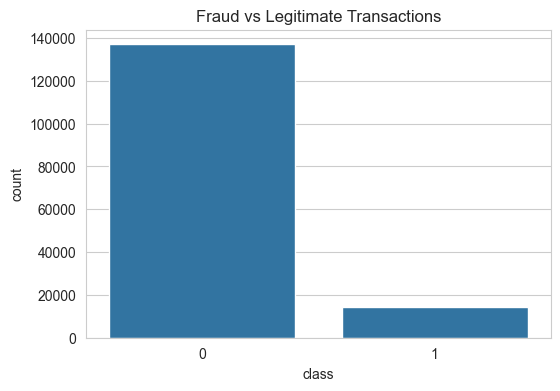

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=fraud_df,
    x="class"
)

plt.title("Fraud vs Legitimate Transactions")
plt.show()

The dataset exhibits class imbalance, with legitimate transactions significantly outnumbering fraudulent transactions. This imbalance must be addressed during model training using resampling techniques such as SMOTE.

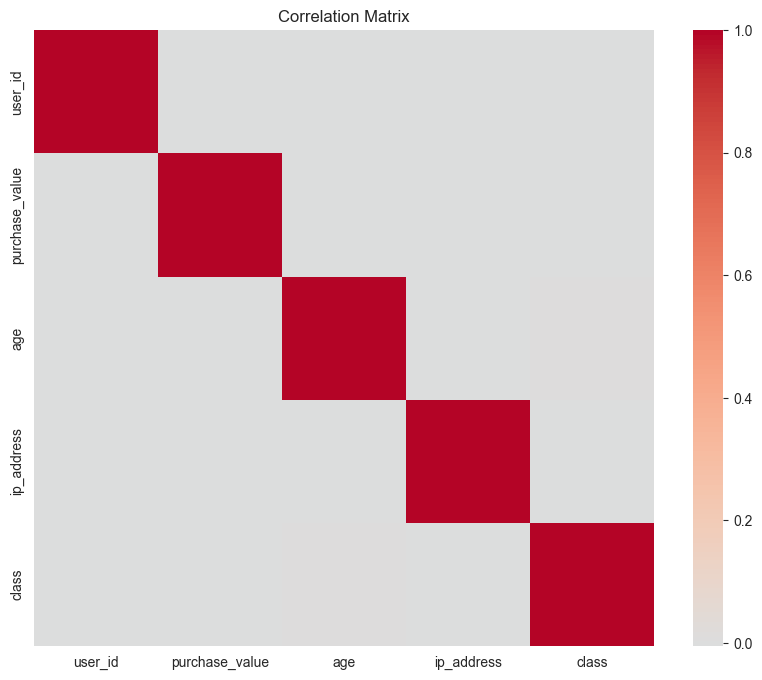

In [35]:
numeric_cols = fraud_df.select_dtypes(
    include=np.number
)

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

## Purchase Value Distribution

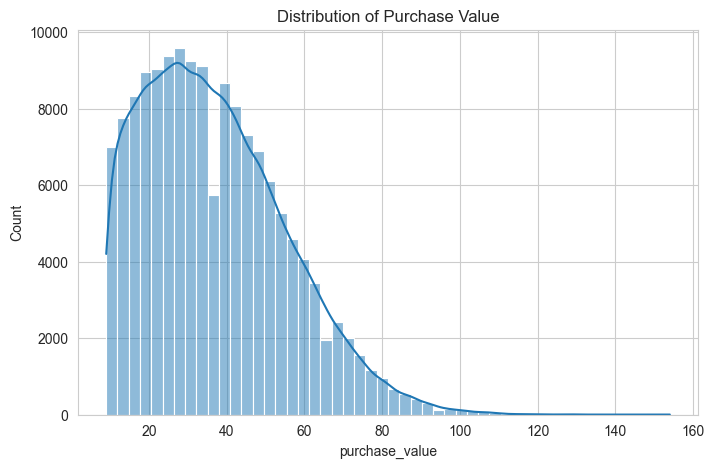

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    fraud_df["purchase_value"],
    bins=50,
    kde=True
)

plt.title("Distribution of Purchase Value")

plt.show()

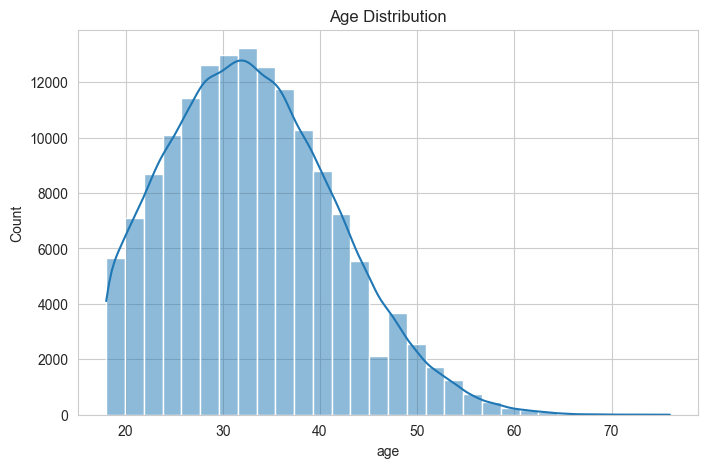

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    fraud_df["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

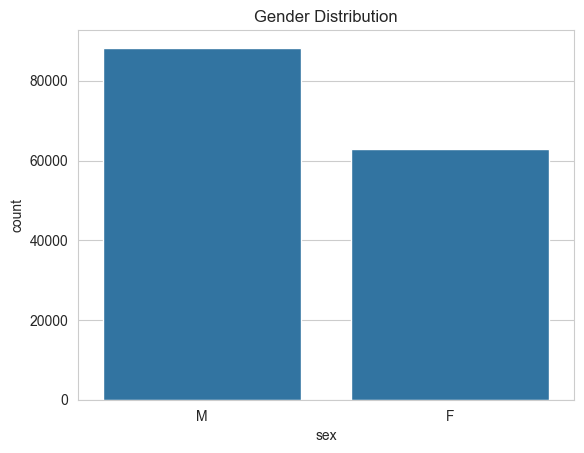

In [25]:
sns.countplot(
    data=fraud_df,
    x="sex"
)

plt.title("Gender Distribution")

plt.show()

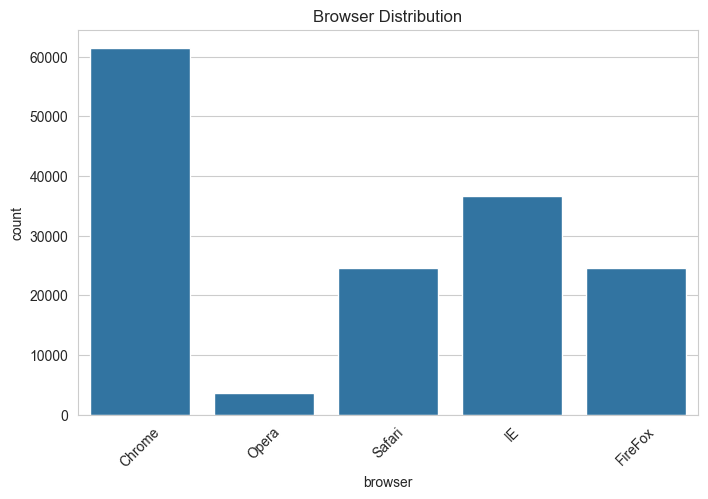

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fraud_df,
    x="browser"
)

plt.title("Browser Distribution")

plt.xticks(rotation=45)

plt.show()

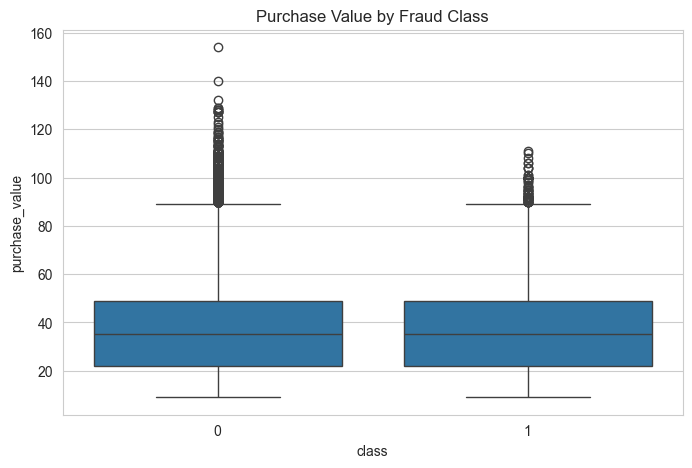

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=fraud_df,
    x="class",
    y="purchase_value"
)

plt.title(
    "Purchase Value by Fraud Class"
)

plt.show()

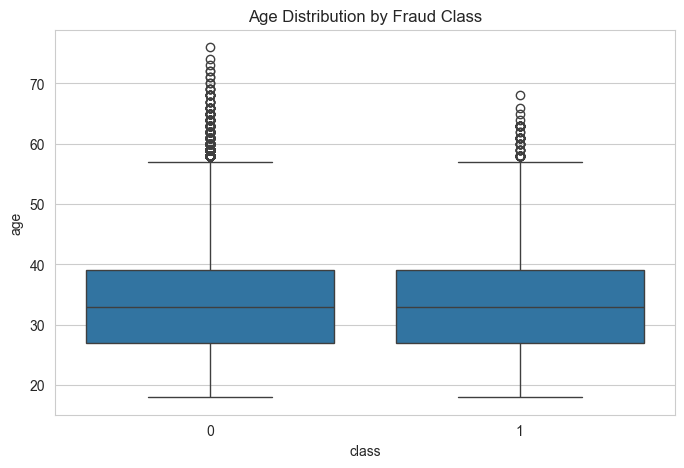

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=fraud_df,
    x="class",
    y="age"
)

plt.title(
    "Age Distribution by Fraud Class"
)

plt.show()

In [29]:
browser_fraud = pd.crosstab(
    fraud_df["browser"],
    fraud_df["class"],
    normalize="index"
)

browser_fraud

class,0,1
browser,,
Chrome,0.901208,0.098792
FireFox,0.904835,0.095165
IE,0.913225,0.086775
Opera,0.910773,0.089227
Safari,0.909799,0.090201


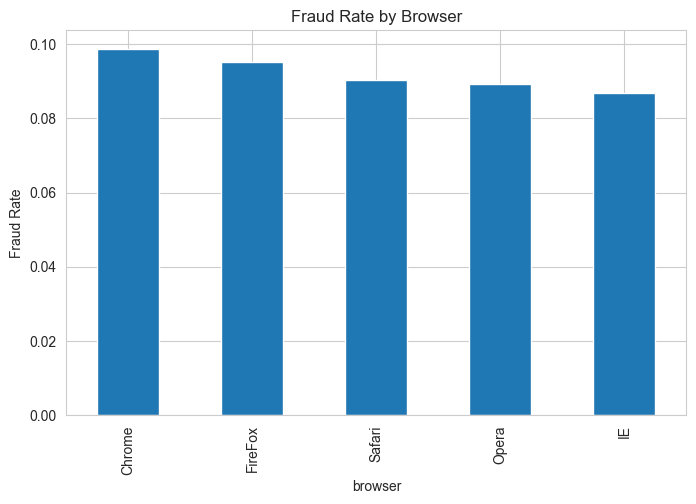

In [30]:
browser_fraud[1].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Fraud Rate by Browser")

plt.ylabel("Fraud Rate")

plt.show()

In [31]:
source_fraud = pd.crosstab(
    fraud_df["source"],
    fraud_df["class"],
    normalize="index"
)

source_fraud


class,0,1
source,,
Ads,0.907934,0.092066
Direct,0.894630,0.105370
SEO,0.910715,0.089285


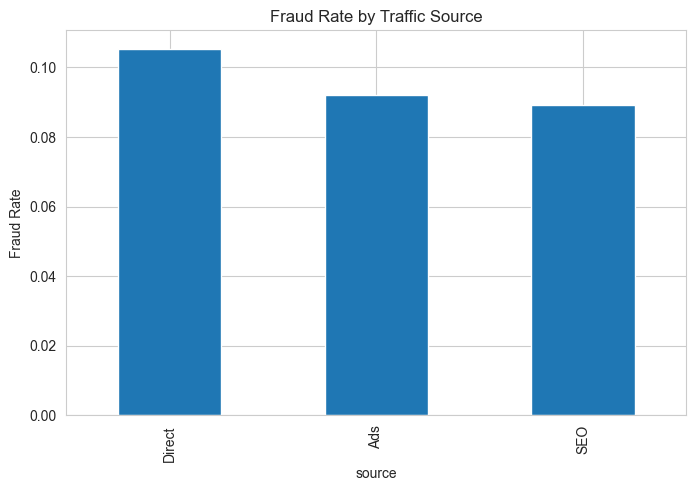

In [39]:
source_fraud[1].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Fraud Rate by Traffic Source")

plt.ylabel("Fraud Rate")

plt.show()

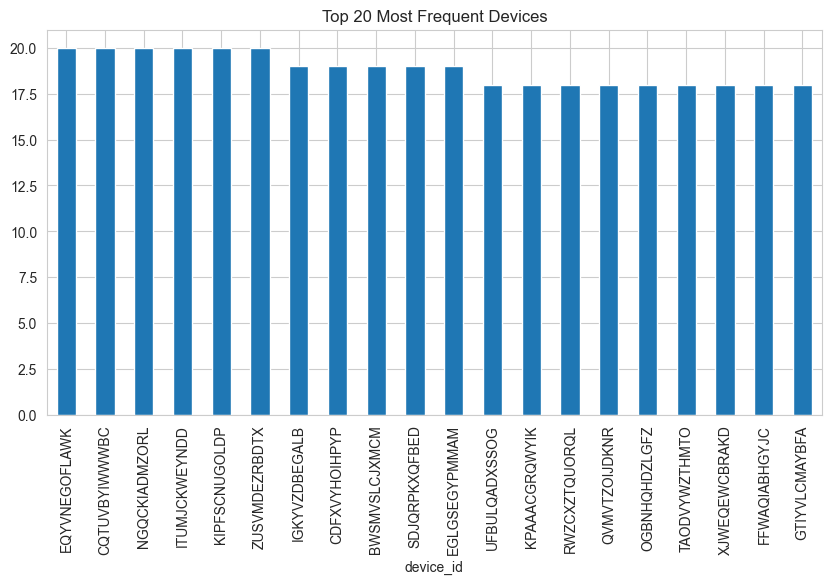

In [36]:
top_devices = fraud_df["device_id"].value_counts().head(20)

top_devices.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Top 20 Most Frequent Devices"
)

plt.show()

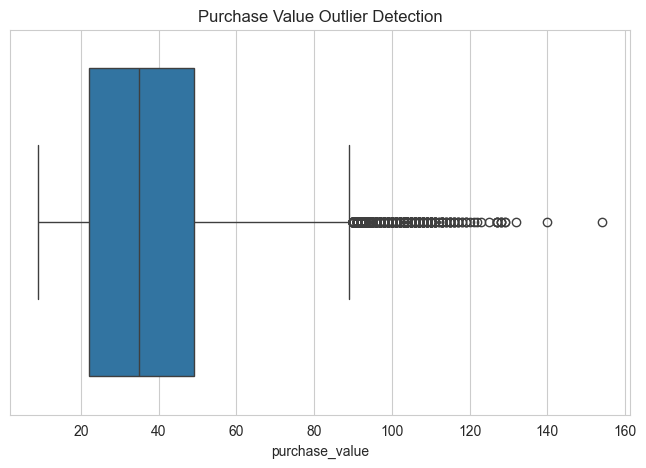

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=fraud_df["purchase_value"]
)

plt.title(
    "Purchase Value Outlier Detection"
)

plt.show()

## Save Clean Dataset

In [33]:
fraud_df.to_csv(
    "../data/processed/fraud_clean.csv",
    index=False
)

In [38]:
plt.savefig(
    "../reports/figures/class_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>